# Shape Interest Classifier

This notebook demonstrates how to train a supervised machine learning model to identify shapes of interest from a set of contours. We use **Hu Invariants** as features and **scikit-learn** for the classifier.
Class 1: shape of interest
Class 0: other shapes

## Key Steps:
1. **Feature Extraction**: Calculate log-transformed Hu Moments for each contour.
2. **Preprocessing**: Scale features using `StandardScaler`.
3. **Model Training**: Train a `RandomForestClassifier` (or any other scikit-learn model).
4. **Inference**: Use the trained model to find shapes of interest in new sets of contours.

In [9]:
import cv2
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from icecream import ic
import pandas as pd

In [10]:
def extract_hu_features(contour):
    """
    Extracts log-transformed Hu Moments from an OpenCV contour.
    These features are invariant to translation, scale, and rotation.
    """
    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Log transform to handle varying dynamic ranges
    log_hu = []
    for m in hu_moments:
        if m != 0:
            log_hu.append(-1.0 * np.sign(m) * np.log10(np.abs(m)))
        else:
            log_hu.append(0.0)
            
    return np.array(log_hu)

## 1. Prepare Training Data

Assuming you have a list of contours and their corresponding labels (1 for 'of interest', 0 for 'not of interest').

Here we provide a mock data generation if you don't have your data loaded yet.

In [11]:
# If you have your data in a specific format, load it here.
# Example:
# training_contours = [...]  # List of numpy arrays (contours)
# training_labels = [...]    # List of 0s and 1s

def generate_mock_data():
    """Generates synthetic contours (Squares vs Triangles) for demonstration."""
    contours = []
    labels = []
    
    square = np.array([[-20,-20], [20,-20], [20,20], [-20,20]], dtype=np.int32)
    triangle = np.array([[0,-25], [22,15], [-22,15]], dtype=np.int32)
    
    for _ in range(50):
        scale = np.random.uniform(0.5, 2.5)
        angle = np.random.uniform(0, 2 * np.pi)
        tx, ty = np.random.randint(100, 400, size=2)
        rot_mat = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
        
        # Square (Interest)
        transformed = (square * scale) @ rot_mat.T + [tx, ty]
        contours.append(transformed.astype(np.int32).reshape(-1, 1, 2))
        labels.append(1)
        
        # Triangle (Not Interest)
        transformed = (triangle * scale) @ rot_mat.T + [tx, ty]
        contours.append(transformed.astype(np.int32).reshape(-1, 1, 2))
        labels.append(0)
        
    return contours, labels


def import_trainset():   
    with open('shape_interest_training_data.pkl', 'rb') as f:
        assets = pickle.load(f)  
    training_labels = assets['training_labels']
    training_contours = assets['training_contours']
    
    return training_contours, training_labels

# ic('mock')
# training_contours, training_labels = generate_mock_data()
# ic(len(training_contours), len(training_labels));
# ic(training_contours[0], training_labels[0]);

ic('imported')
training_contours, training_labels = import_trainset()
ic(len(training_contours), len(training_labels));
# ic(training_contours[0], training_labels[0]);


ic| 'imported'
ic| len(training_contours): 1557, len(training_labels): 1557


## 2. Feature Extraction and Preprocessing

In [12]:
# Extract features
X = np.array([extract_hu_features(cnt) for cnt in training_contours])
y = np.array(training_labels)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Feature matrix shape: {X_train_scaled.shape}")

Feature matrix shape: (1245, 7)


## 3. Train the Model

In [13]:
# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# Evaluate
y_pred = clf.predict(X_val_scaled)
print("Classification Report:")
print(classification_report(y_val, y_pred))

# Save the model and scaler for later use
with open('shape_interest_model.pkl', 'wb') as f:
    pickle.dump({'model': clf, 'scaler': scaler}, f)
print("Model and scaler saved to 'shape_interest_model.pkl'.")

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       230
           1       0.95      0.95      0.95        82

    accuracy                           0.97       312
   macro avg       0.97      0.97      0.97       312
weighted avg       0.97      0.97      0.97       312

Model and scaler saved to 'shape_interest_model.pkl'.


## 4. Inference on New Contours

Function to use the trained model on a new list of contours.

In [14]:
def find_shapes_of_interest(new_contours, model_path='shape_interest_model.pkl'):
    """
    Loads the model and scaler, extracts features from new contours, 
    and returns those identified as 'of interest'.
    """
    with open(model_path, 'rb') as f:
        assets = pickle.load(f)
    
    model = assets['model']
    scaler = assets['scaler']
    
    if not new_contours:
        return []
    
    # Extract and scale features
    features = np.array([extract_hu_features(cnt) for cnt in new_contours])
    scaled_features = scaler.transform(features)
    
    # Predict
    predictions = model.predict(scaled_features)
    
    # Filter contours of interest
    interest_contours = [cnt for cnt, pred in zip(new_contours, predictions) if pred == 1]
    
    return interest_contours

# Example usage with some new mock data
new_test_contours, _ = generate_mock_data()
found_shapes = find_shapes_of_interest(new_test_contours)
print(f"Found {len(found_shapes)} shapes of interest out of {len(new_test_contours)} new contours.")

Found 86 shapes of interest out of 100 new contours.


## Visualization

Visualize some of the detected shapes.

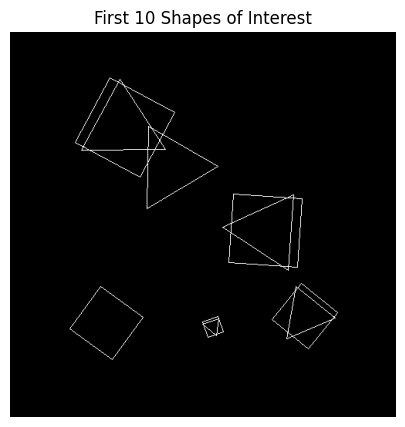

In [15]:
def plot_contours(contours, title="Detected Shapes"):
    plt.figure(figsize=(10, 5))
    canvas = np.zeros((500, 500), dtype=np.uint8)
    cv2.drawContours(canvas, contours, -1, 255, 1)
    plt.imshow(canvas, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

if found_shapes:
    plot_contours(found_shapes[:10], "First 10 Shapes of Interest")